# [Credit Card Data from book "Econometric Analysis"](www.kaggle.com/datasets/dansbecker/aer-credit-card-data)*

Prediction models for attribution of credit card

# Preamble

In [1]:
load = True

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
pd.set_option('future.no_silent_downcasting', True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

import optuna

2025-09-04 00:06:35.203466: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/rl/anaconda3/envs/credit/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def visual_hists(df, col):
    fig, axes = plt.subplots(nrows=3, ncols=4,
                            figsize=(30, 12))
    cnt = 0
    for i in range(np.shape(axes)[0]):
        for j in range(np.shape(axes)[1]):
            if cnt == 0:
                density=False
            else:
                density=True
            #print(cnt, df.columns[cnt])
            _, bins = np.histogram(df.iloc[:, cnt], bins=10)
            hist0, _ = np.histogram(df[df[col] == 0].iloc[:, cnt], bins = bins, density=density)
            hist1, _ = np.histogram(df[df[col] == 1].iloc[:, cnt], bins = bins, density=density)
            axes[i, j].stairs(hist0, edges = bins, color="black", lw=4)
            axes[i, j].stairs(hist1, edges = bins, color="red", lw=4)
            axes[i, j].set_title(df.columns[cnt])
            cnt+=1

In [3]:
def optuna_study(function, study_name, direction, storage="sqlite:///db.sqlite3", n_trials=50, delete_study=False, load=True):
    
    def objective(trial):
        return function(trial)

    if not load:
        if delete_study:
            optuna.delete_study(
                study_name = study_name,
                storage = storage
            )
        study = optuna.create_study(
            direction = direction,
            study_name = study_name,
            storage = storage,
            load_if_exists = True
        )

        study.optimize(objective, n_trials=n_trials)

    else:
        study = optuna.load_study(
            study_name = study_name,
            storage = storage
        )
        
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    trial = study.best_trial
    print("  Value: ", trial.value)
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

    return study, trial


# Data

## Data Import and Preprocessing

In [4]:
#import data
df = pd.read_csv("AER_credit_card_data.csv")
df.head()
df.describe()


,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


In [5]:
#turn boolean to binary features
df = df.replace({"yes": 1, "no": 0})
for c in df.columns:
    df[c] = pd.to_numeric(df[c])
df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


In [6]:
#separate data in train and testing subsets
train, test = train_test_split(df, train_size=0.75)

In [7]:
#standardize all columns that are not binary (boolean)
cols = ["reports", "age", "income", "share", "expenditure", "dependents", "months", "active"] #columns to standardize
scaler = StandardScaler()

TRAIN = train.copy()
TRAIN[cols] = scaler.fit_transform(TRAIN[cols])

TEST = test.copy()
TEST[cols] = scaler.transform(TEST[cols])

## Data Visualization

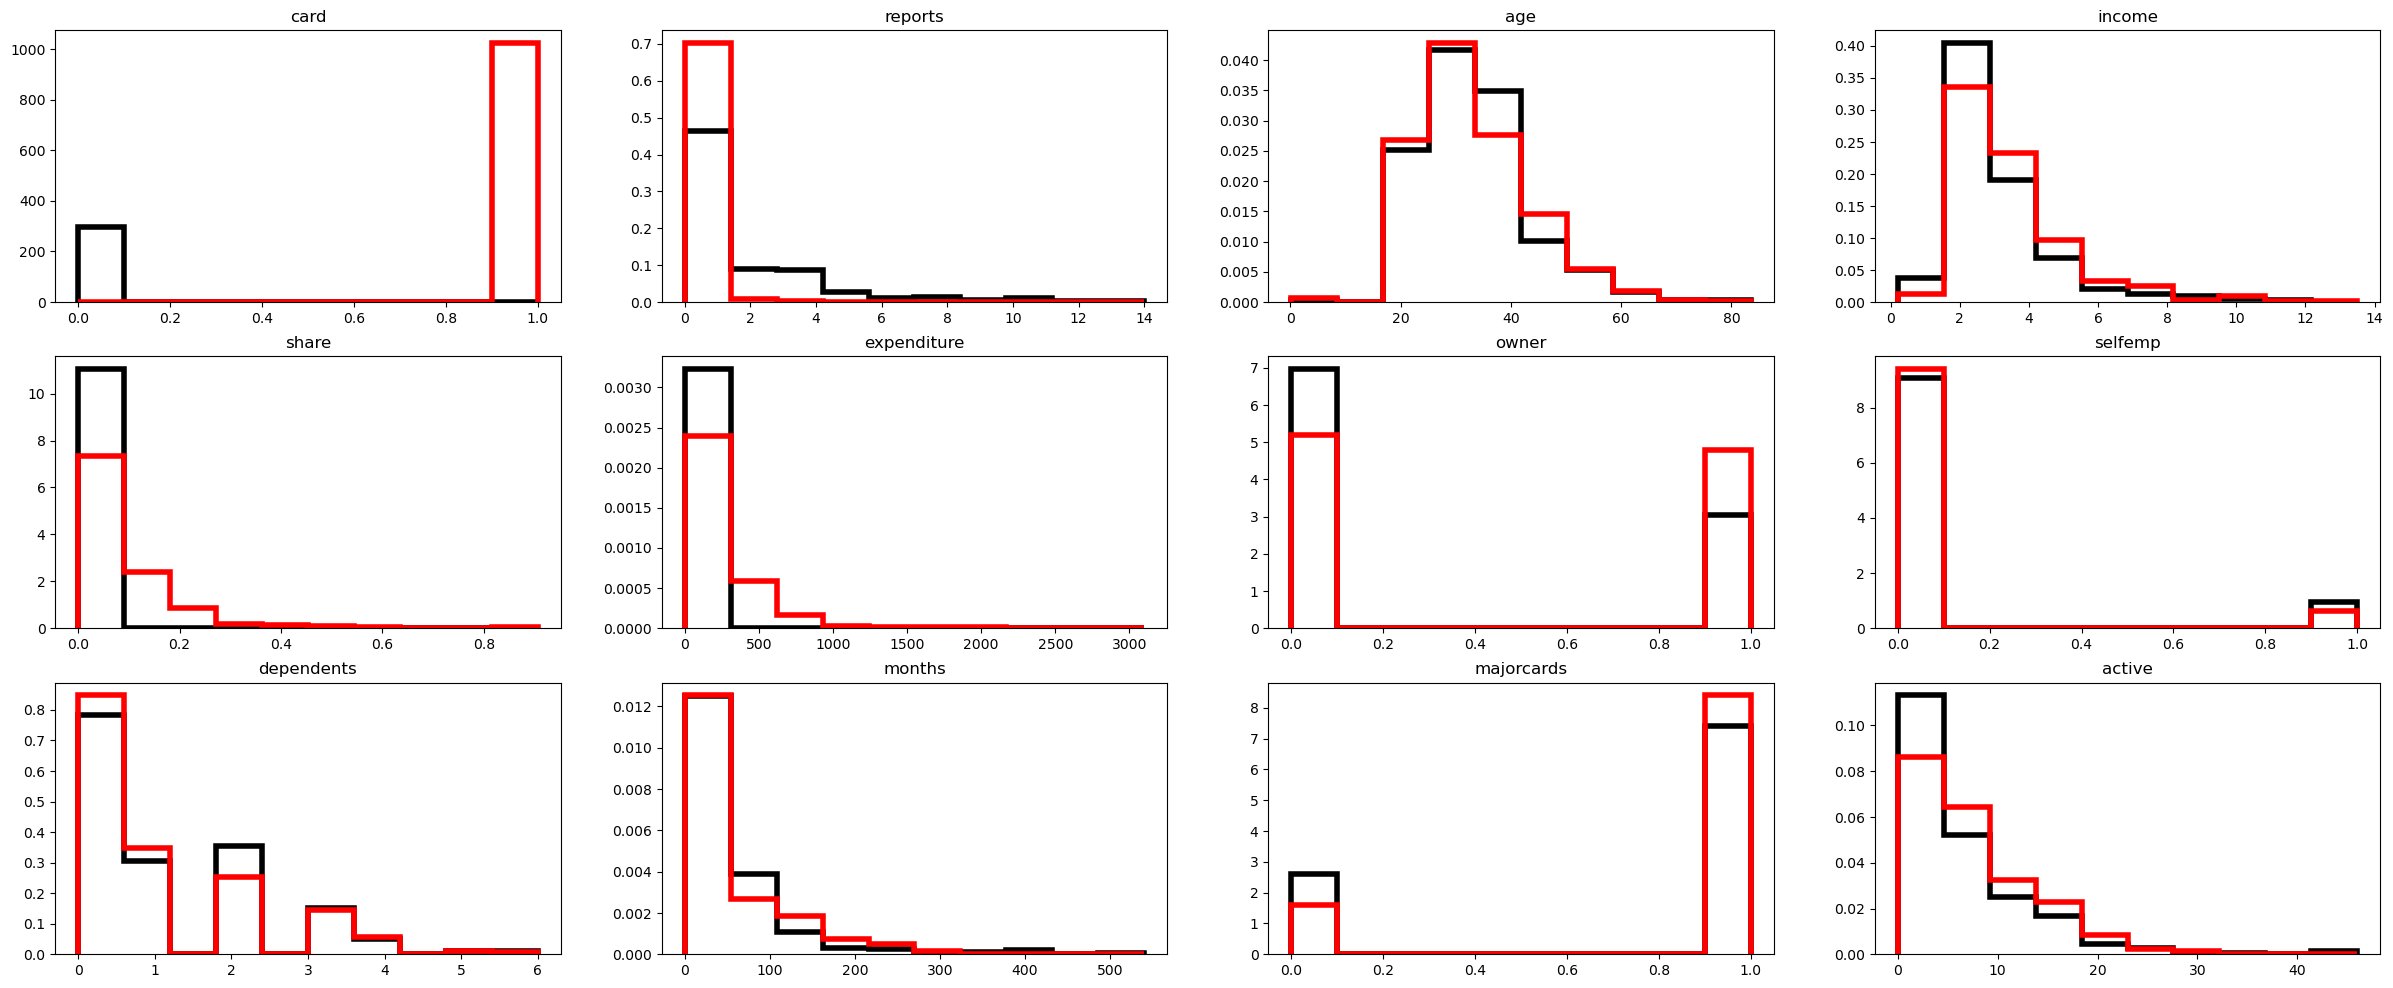

In [8]:
visual_hists(df, "card")

# Clustering Techniques

## K Means

### Ideal number of cluster (5)

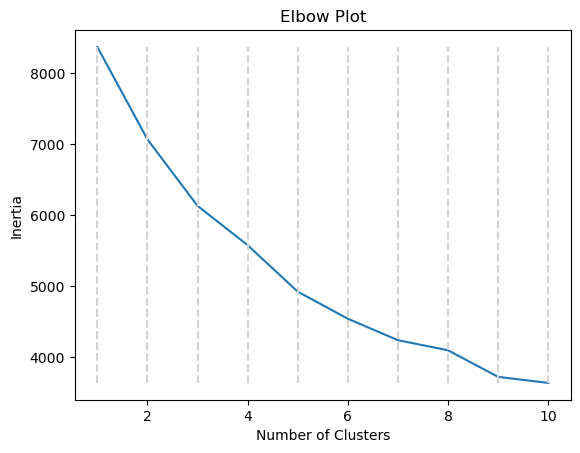

In [9]:
inertia = []
for i in range(10):
    kmeans = KMeans(n_clusters=i+1)
    inertia.append(kmeans.fit(TRAIN.iloc[:, 1:]).inertia_)
plt.plot(np.arange(1, 11), inertia)
plt.vlines(x = np.arange(1, 11), ymin=min(inertia), ymax=max(inertia),
           color="lightgrey", linestyle="dashed")
plt.title("Elbow Plot")
plt.ylabel("Inertia")
plt.xlabel("Number of Clusters")
plt.show()

In [10]:
def k_objective(trial):
    kmeans = KMeans(
        n_clusters = 5,
        init = trial.suggest_categorical("init", ["k-means++", "random"]),
        n_init = trial.suggest_int("n_init", 5, 20),
        max_iter = trial.suggest_int("max_iter", 40, 100),
        tol = trial.suggest_float("tol", 1e-4, 1e-1, log=True),
        algorithm = trial.suggest_categorical("algorithm", ["lloyd", "elkan"]),
        random_state = 100
    )
    return kmeans.fit(TRAIN.iloc[:, 1:]).inertia_

k5study, k5trial = optuna_study(function=k_objective, 
                              study_name="K5Means_Clusters", 
                              direction="minimize", 
                              n_trials=100, 
                              delete_study=False,
                              load=True)


Number of finished trials:  100
Best trial:
  Value:  4978.568532563588
  Params: 
    init: random
    n_init: 14
    max_iter: 88
    tol: 0.00010079599615497491
    algorithm: elkan


In [11]:
#choose two clusters
k5means = KMeans(
        n_clusters = 5,
        init = k5trial.params["init"],
        n_init = k5trial.params["n_init"],
        max_iter = k5trial.params["max_iter"],
        tol = k5trial.params["tol"],
        algorithm = k5trial.params["algorithm"],
        random_state = 100
    )
k5means.fit(TRAIN.iloc[:, 1:].values)
train["k5cluster"] = k5means.predict(TRAIN.iloc[:, 1:].values)
test["k5cluster"] = k5means.predict(TEST.iloc[:, 1:].values)
#print(f'K Cluster Accuracy: {100*accuracy_score(test.card, test.kcluster):.2f}%')

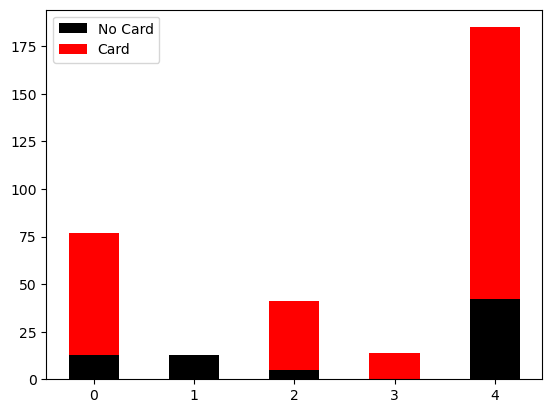

In [12]:
bins = np.arange(-0.5, 5.5, 1)
plt.hist([test[test.card == 0].k5cluster, test[test.card == 1].k5cluster],
         bins=bins, label=["No Card", "Card"], color=["black", "red"], 
         stacked=True, rwidth=0.5)
plt.legend()

### KMeans Two Clusters

In [13]:
def k_objective(trial):
    kmeans = KMeans(
        n_clusters = 2,
        init = trial.suggest_categorical("init", ["k-means++", "random"]),
        n_init = trial.suggest_int("n_init", 5, 20),
        max_iter = trial.suggest_int("max_iter", 40, 100),
        tol = trial.suggest_float("tol", 1e-4, 1e-1, log=True),
        algorithm = trial.suggest_categorical("algorithm", ["lloyd", "elkan"]),
        random_state = 100
    )
    return kmeans.fit(TRAIN.iloc[:, 1:]).inertia_

k2study, k2trial = optuna_study(function=k_objective, 
                              study_name="K2Means_Clusters", 
                              direction="minimize", 
                              n_trials=100, 
                              delete_study=False,
                              load=True)


Number of finished trials:  100
Best trial:
  Value:  7064.133644729468
  Params: 
    init: random
    n_init: 16
    max_iter: 40
    tol: 0.00016965654660575124
    algorithm: lloyd


In [14]:
#choose two clusters
k2means = KMeans(
        n_clusters = 2,
        init = k2trial.params["init"],
        n_init = k2trial.params["n_init"],
        max_iter = k2trial.params["max_iter"],
        tol = k2trial.params["tol"],
        algorithm = k2trial.params["algorithm"],
        random_state = 100
    )
k2means.fit(TRAIN.iloc[:, 1:].values)
train["k2cluster"] = k2means.predict(TRAIN.iloc[:, 1:].values)
test["k2cluster"] = k2means.predict(TEST.iloc[:, 1:].values)
print(f'K Cluster Accuracy: {100*accuracy_score(test.card, test.k2cluster):.2f}%')

K Cluster Accuracy: 40.91%


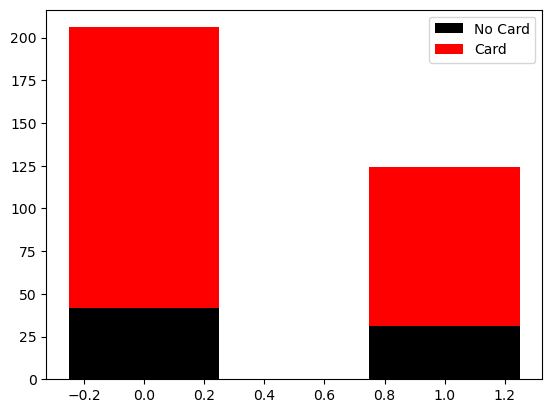

In [15]:
bins = np.arange(-0.5, 2.5, 1)
plt.hist([test[test.card == 0].k2cluster, test[test.card == 1].k2cluster],
         bins=bins, label=["No Card", "Card"], color=["black", "red"], 
         stacked=True, rwidth=0.5)
plt.legend()

## PCA

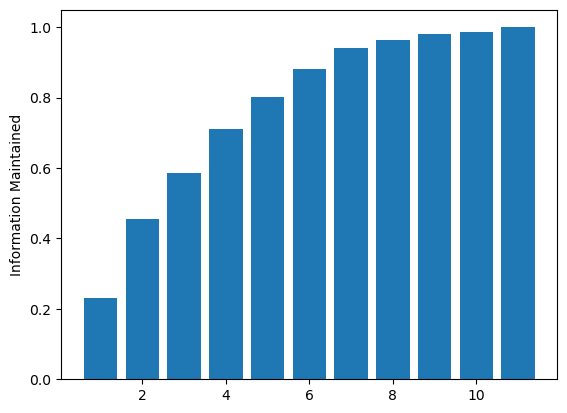

In [16]:
Z = TRAIN.iloc[:, 1:]
C = Z.cov()

lambdas, vs = np.linalg.eig(C)

plt.bar(np.arange(1, len(lambdas)+1), np.cumsum(lambdas/sum(lambdas)))
plt.ylabel("Information Maintained")
plt.show()


In [17]:
train.k5cluster.value_counts()

k5cluster
4    552
0    220
2    129
3     46
1     42
Name: count, dtype: int64

/tmp/ipykernel_283165/112591647.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20b", 5)  # "tab10" has good distinct colors, limit to 5
/home/rl/anaconda3/envs/credit/lib/python3.11/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


<function matplotlib.pyplot.show(close=None, block=None)>

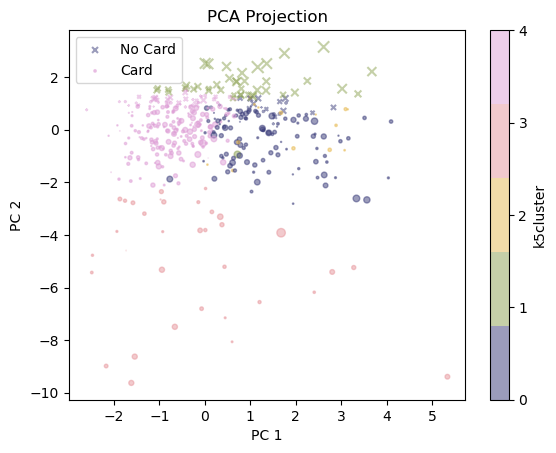

In [18]:
proj = Z.dot(vs)
fig, ax = plt.subplots()

# Define markers for card
markers = {0: "x", 1: "o"}

# Define a colormap with 5 distinct colors
cmap = cm.get_cmap("tab20b", 5)  # "tab10" has good distinct colors, limit to 5

for i in [0, 1]:
    cond = train.card == i
    scatter = ax.scatter(
        proj[cond].iloc[:, 0],
        proj[cond].iloc[:, 1],
        c=train.loc[cond, "k5cluster"], 
        cmap=cmap,
        alpha=0.5,
        s=proj[cond].iloc[:, 2]*10,
        marker=markers[i],
        label=["No Card", "Card"][i]
    )

plt.legend()
plt.ylabel("PC 2")
plt.xlabel("PC 1")
plt.title("PCA Projection")

# Add a colorbar to show k5cluster mapping
cbar = plt.colorbar(scatter, ax=ax, ticks=np.arange(5))
cbar.set_label("k5cluster")

plt.show



/tmp/ipykernel_283165/2854048644.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20b", 2)


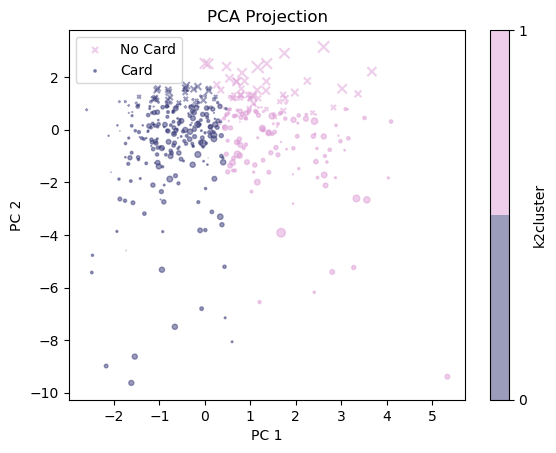

In [19]:
fig, ax = plt.subplots()
cmap = cm.get_cmap("tab20b", 2)
for i in [0, 1]:
    cond = train.card == i
    scatter = ax.scatter(
        proj[cond].iloc[:, 0],
        proj[cond].iloc[:, 1],
        c=train.loc[cond, "k2cluster"],  # cluster values
        cmap=cmap,
        alpha=0.5,
        s=proj[cond].iloc[:, 2]*10,
        marker=markers[i],
        label=["No Card", "Card"][i]
    )

plt.legend()
plt.ylabel("PC 2")
plt.xlabel("PC 1")
plt.title("PCA Projection")

# Add a colorbar to show k2cluster mapping
cbar = plt.colorbar(scatter, ax=ax, ticks=np.arange(2))
cbar.set_label("k2cluster")

plt.show()

# Classification / Regression

## Support Vector Machine

There is need to be extremely careful with overfitting. The regularization factor must be well under 1. The kernel must not be polynomial ("ploy").

In [20]:
def svm_objective(trial):

    svm = SVC(C= trial.suggest_float("C", 1e-3, 0.3, log=True),
              kernel= trial.suggest_categorical("kernel", ["linear", "rbf", "sigmoid"]),
              degree= trial.suggest_int("degree", 1, 5),
              gamma = trial.suggest_float("gamma", 1e-2, 1),
              probability = True,
              random_state=100)  
    svm.fit(TRAIN.iloc[:, 1:], TRAIN.card)
    pred = svm.predict(TRAIN.iloc[:, 1:])
    return  accuracy_score(TRAIN.card, pred)

svm_study = optuna.create_study(
    direction = "maximize",
    study_name = "Credit_SVM",
    storage = "sqlite:///db.sqlite3",
    load_if_exists = True
)

svm_study, svm_trial = optuna_study(  
                            function=svm_objective,
                            study_name="Credit_SVM",
                            n_trials=100,
                            direction="maximize",
                            delete_study=True
                        )


[I 2025-09-04 00:06:42,053] Using an existing study with name 'Credit_SVM' instead of creating a new one.


Number of finished trials:  100
Best trial:
  Value:  0.9474216380182002
  Params: 
    C: 0.20452806493842457
    kernel: linear
    degree: 3
    gamma: 0.5423331473370508


In [21]:
svm = SVC(
    C= svm_trial.params["C"],
    kernel= svm_trial.params["kernel"],
    degree= svm_trial.params["degree"],
    gamma = svm_trial.params["gamma"],
    probability = True,
    random_state=100
)   
svm.fit(TRAIN.iloc[:, 1:], TRAIN.card)
train["svmclass"] = svm.predict(TRAIN.iloc[:, 1:])
test["svmclass"] = svm.predict(TEST.iloc[:, 1:])
print(f'SVM Train Accuracy: {100*accuracy_score(train.card, train.svmclass):.2f}%')
print(f'SVM Tree Test Accuracy: {100*accuracy_score(test.card, test.svmclass):.2f}%')

SVM Train Accuracy: 94.54%
SVM Tree Test Accuracy: 92.73%


Accuracy is similar between train and test dataset, implying that we avoided an overfit. Observing the feature importance reinforces this idea. The SVM seems to generalize well.

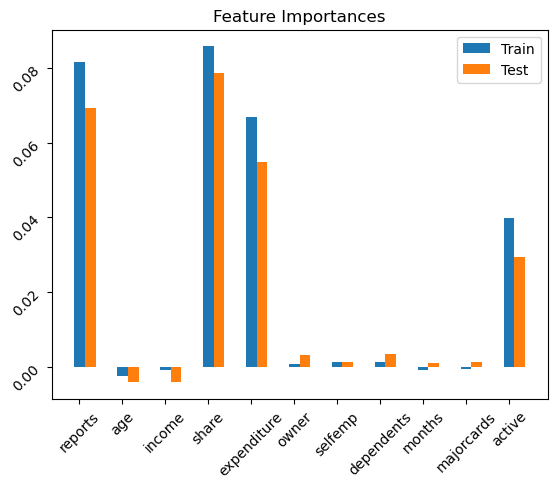

In [22]:
train_results = permutation_importance(svm, TRAIN.iloc[:, 1:], TRAIN.card, n_repeats=10, random_state=42)
test_results = permutation_importance(svm, TEST.iloc[:, 1:], TEST.card, n_repeats=10, random_state=42)

#for i, importance in enumerate(results.importances_mean):
#    print(f"Feature {i+1}: {importance}")
width = 0.25
fig, ax = plt.subplots()
ax.bar(np.arange(1, len(train_results.importances_mean)+1),
       train_results.importances_mean, width=width, label="Train")
ax.bar(np.arange(1, len(test_results.importances_mean)+1)+width,
       test_results.importances_mean, width=width, label="Test")

ax.set_xticks(ticks = np.arange(1,len(df.columns[1:12])+1),
                   labels = df.columns[1:12])
ax.tick_params(labelrotation=45)
plt.title("Feature Importances")
plt.legend()

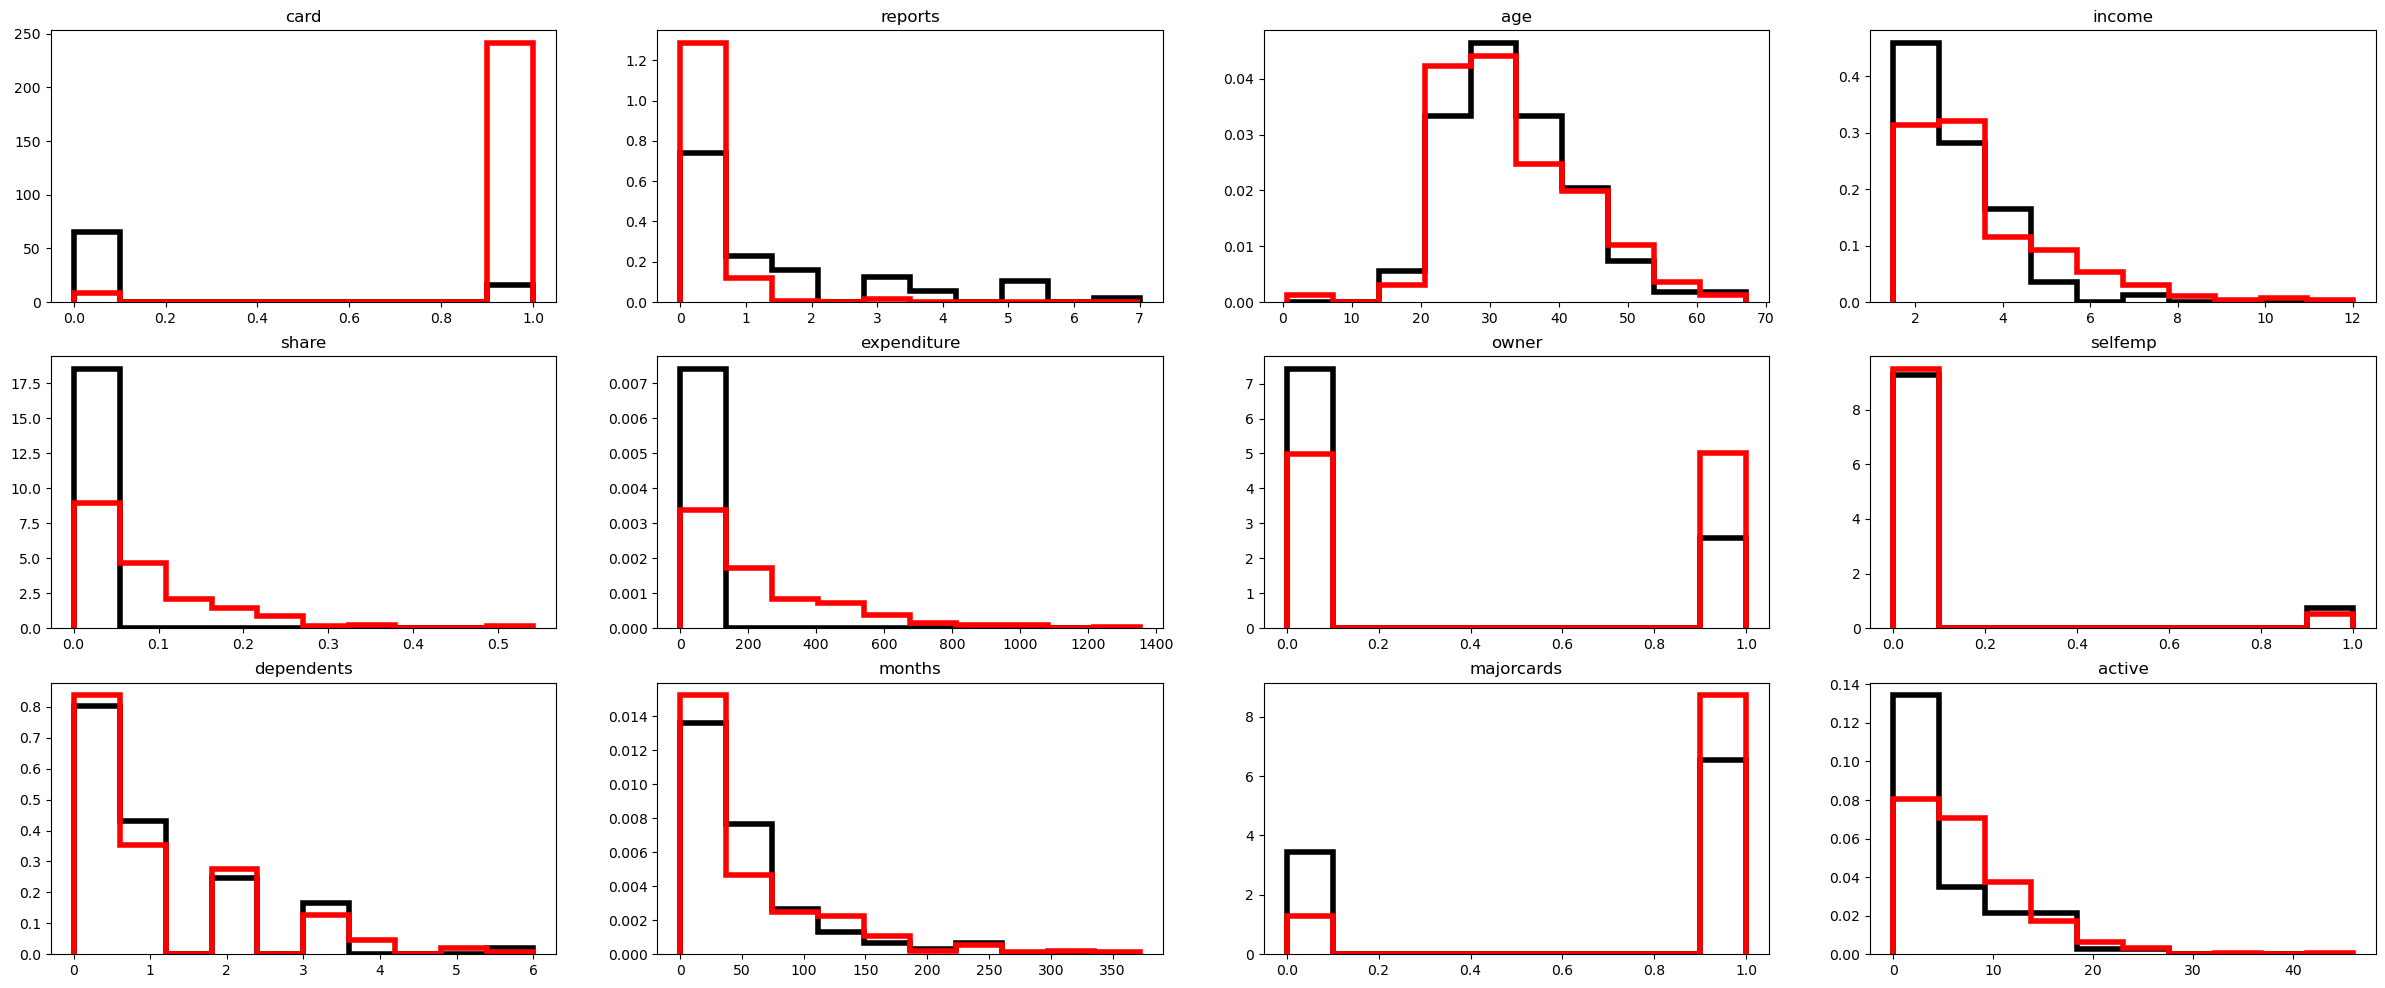

In [23]:
visual_hists(test, "svmclass")

## Decision Tree Classifier

In [24]:
#max_depth is important to avoid overfit
def clf_objective(trial):
    max_depth = trial.suggest_int("max_depth", 2, 8)
    criterion = trial.suggest_categorical("criterion", ["squared_error", "friedman_mse", "absolute_error", "poisson"])
    splitter = trial.suggest_categorical("splitter", ["best", "random"])
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 10, step=2)

    clf = DecisionTreeRegressor(random_state=100,
                                 criterion = criterion, 
                                 splitter = splitter,           
                                 max_depth = max_depth,
                                max_features = max_features,
                                max_leaf_nodes = max_leaf_nodes)
    clf.fit(TRAIN.iloc[:, 1:], TRAIN.card)
    pred = clf.predict(TRAIN.iloc[:, 1:]) > 0.5
    acc = accuracy_score(TRAIN.card, pred)
    return acc

clf_study, clf_trial = optuna_study(function=clf_objective, 
                              study_name="Credit_Decision_Tree", 
                              direction="maximize", 
                              n_trials=100, 
                              delete_study=False,
                              load=True)




Number of finished trials:  200
Best trial:
  Value:  0.9908998988877654
  Params: 
    max_depth: 7
    criterion: squared_error
    splitter: best
    max_features: None
    max_leaf_nodes: 10


In [25]:
#train with best parameters
clf = DecisionTreeRegressor(random_state=100,
                            criterion = clf_trial.params["criterion"], 
                            splitter = clf_trial.params["splitter"],           
                            max_depth = clf_trial.params["max_depth"],
                            max_features = clf_trial.params["max_features"],
                            max_leaf_nodes = clf_trial.params["max_leaf_nodes"])

clf.fit(TRAIN.iloc[:, 1:], TRAIN.card)
train["treepred"] = clf.predict(TRAIN.iloc[:, 1:])
test["treepred"] = clf.predict(TEST.iloc[:, 1:])
train["treeclass"] = clf.predict(TRAIN.iloc[:, 1:]) > 0.5
test["treeclass"] = clf.predict(TEST.iloc[:, 1:]) > 0.5
print(f'Decision Tree Train Accuracy: {100*accuracy_score(train.card, train.treeclass):.2f}%')
print(f'Decision Tree Test Accuracy: {100*accuracy_score(test.card, test.treeclass):.2f}%')

Decision Tree Train Accuracy: 99.29%
Decision Tree Test Accuracy: 97.27%


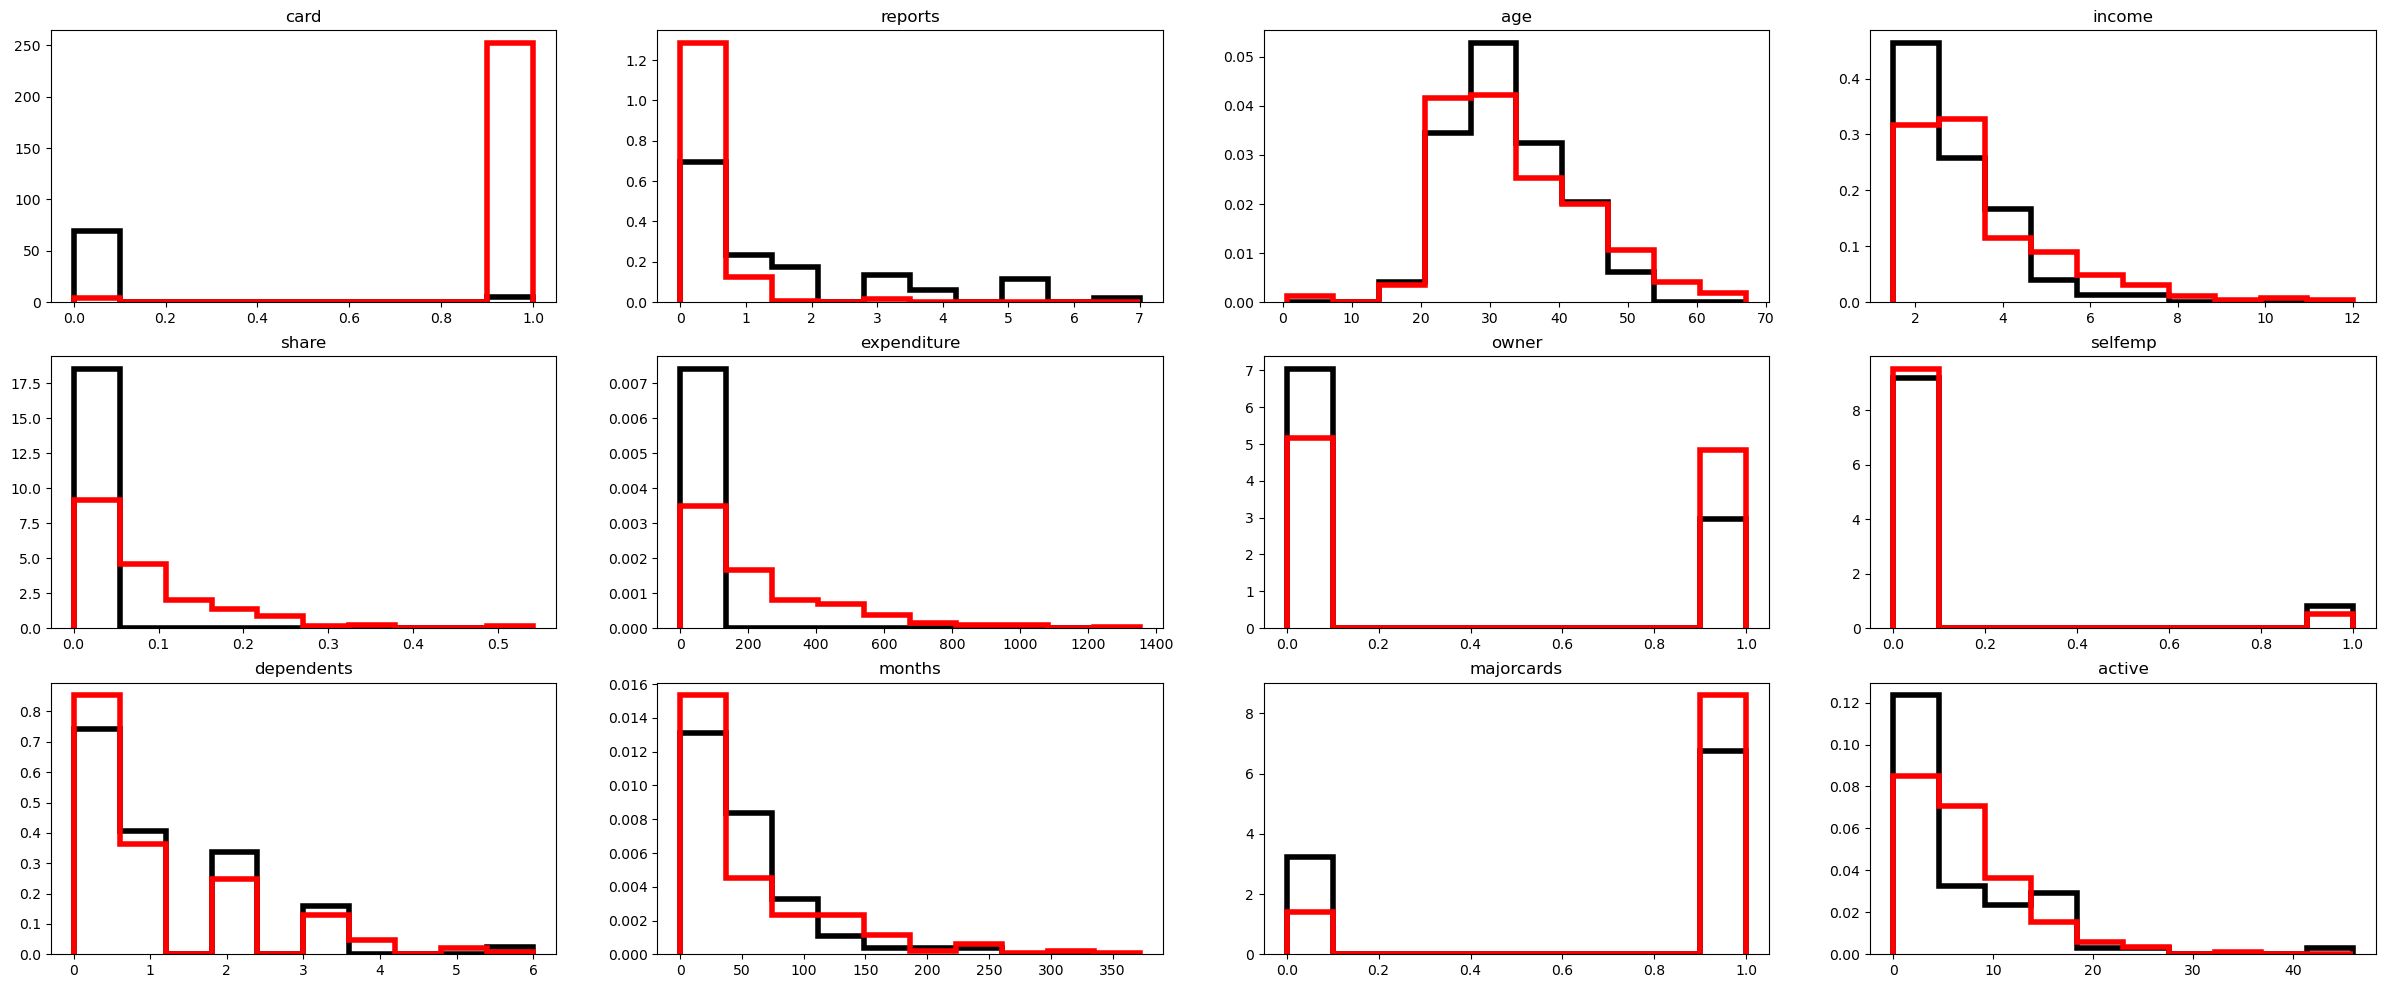

In [26]:
visual_hists(test, "treeclass")

In [27]:
len(np.arange(1, len(clf.feature_importances_)+1)), len(df.columns[1:12])

(11, 11)

Text(0.5, 1.0, 'Feature Importances')

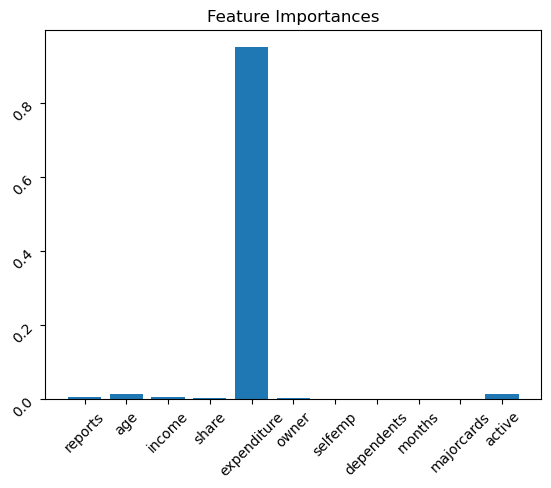

In [28]:
fig, ax = plt.subplots()
ax.bar(np.arange(1, len(clf.feature_importances_)+1),
         clf.feature_importances_)
ax.set_xticks(ticks = np.arange(1, len(clf.feature_importances_)+1),
                   labels = df.columns[1:12])
ax.tick_params(labelrotation=45)
plt.title("Feature Importances")


## Simple Neural Network

In [30]:
## Simple Feedforward Neural Network with Optuna

def nn_objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f"n_units_l{i}", 4, 64, log=True))
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "selu"])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=(TRAIN.shape[1]-1,)))
    for n_units in layers:
        model.add(tf.keras.layers.Dense(n_units, activation=activation))
        model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="mean_squared_error",
                  metrics=["accuracy"])

    model.fit(TRAIN.iloc[:, 1:], TRAIN.card, 
              validation_split=0.2,
              epochs=100,
              batch_size=32,
              verbose=0,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)])

    loss, accuracy = model.evaluate(TRAIN.iloc[:, 1:], TRAIN.card, verbose=0)
    return accuracy


nn_study, nn_trial = optuna_study(function=nn_objective, 
                              study_name="Credit_Simple_FNN", 
                              direction="maximize", 
                              n_trials=50, 
                              delete_study=False,
                              load=True)

Number of finished trials:  93
Best trial:
  Value:  0.9787664413452148
  Params: 
    n_layers: 4
    n_units_l0: 42
    n_units_l1: 55
    n_units_l2: 6
    n_units_l3: 43
    activation: relu
    learning_rate: 0.0021829990329875837
    dropout_rate: 0.17598081636531984


In [32]:
fnn = tf.keras.Sequential()

layers = []
units = [nn_trial.params[f"n_units_l{i}"] for i in range(nn_trial.params["n_layers"])]
for i in range(nn_trial.params["n_layers"]):
    layers.append(units[i])

fnn.add(tf.keras.layers.InputLayer(shape=(TRAIN.shape[1]-1,)))
for n_units in layers:
    fnn.add(tf.keras.layers.Dense(n_units, activation=nn_trial.params["activation"]))
    fnn.add(tf.keras.layers.Dropout(nn_trial.params["dropout_rate"]))
fnn.add(tf.keras.layers.Dense(1, activation="sigmoid"))

fnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=nn_trial.params["learning_rate"]),
                loss="mean_squared_error",
                metrics=["accuracy"])

fnn.fit(TRAIN.iloc[:, 1:], TRAIN.card, 
            validation_split=0.2,
            epochs=100,
            batch_size=32,
            verbose=1,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7332 - loss: 0.2029 - val_accuracy: 0.7374 - val_loss: 0.1807
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7838 - loss: 0.1442 - val_accuracy: 0.7374 - val_loss: 0.1457
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7838 - loss: 0.1198 - val_accuracy: 0.7374 - val_loss: 0.1327
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7838 - loss: 0.1058 - val_accuracy: 0.7374 - val_loss: 0.1202
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8040 - loss: 0.0914 - val_accuracy: 0.8939 - val_loss: 0.1104
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8989 - loss: 0.0929 - val_accuracy: 0.8990 - val_loss: 0.1106
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9216 - loss: 0.0861 - val_accuracy: 0.8788 - val_loss: 0.1113
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9153 - loss: 0.0857 - val_accuracy: 0.9091 - 

In [33]:
test["fnnpred"] = fnn.predict(TEST.iloc[:, 1:])
test["fnnclass"] = test.fnnpred > 0.5
train["fnnpred"] = fnn.predict(TRAIN.iloc[:, 1:])
train["fnnclass"] = train.fnnpred > 0.5
print(f'FNN Train Accuracy: {100*accuracy_score(train.card, train.fnnclass):.2f}%')
print(f'FNN Test Accuracy: {100*accuracy_score(test.card, test.fnnclass):.2f}%')

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
FNN Train Accuracy: 96.56%
FNN Test Accuracy: 90.91%


In [34]:
train_temp_preds = []
train_acc = []
for i in range(len(df.columns[1:12])):
    rand = TRAIN.copy()
    rand.iloc[:, i] = np.random.normal(loc=TRAIN.iloc[:,i].mean(),
                                       scale=TRAIN.iloc[:,i].std(),  
                                       size=len(rand)).astype(type(rand.iloc[0,i])) 
    train_temp_preds.append( fnn.predict(rand.iloc[:, 1:]) )
    train_acc.append(accuracy_score(train_temp_preds[-1] >0.5, TRAIN.card))

test_temp_preds = []
test_acc = []
for i in range(len(df.columns[1:12])):
    rand = TEST.copy()
    rand.iloc[:, i] = np.random.normal(loc=TEST.iloc[:,i].mean(),
                                       scale=TEST.iloc[:,i].std(),  
                                       size=len(rand)).astype(type(rand.iloc[0,i])) 
    test_temp_preds.append( fnn.predict(rand.iloc[:, 1:]) )
    test_acc.append(accuracy_score(test_temp_preds[-1] >0.5, TEST.card))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


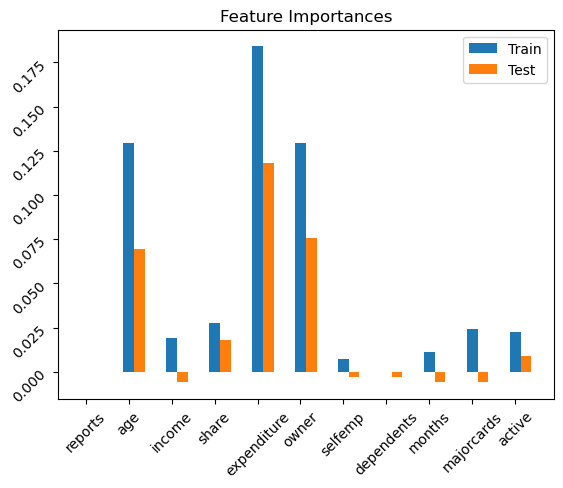

In [35]:
train_results = accuracy_score(train.card, train.fnnclass) - np.array(train_acc)
test_results = accuracy_score(test.card, test.fnnclass) - np.array(test_acc)

#for i, importance in enumerate(results.importances_mean):
#    print(f"Feature {i+1}: {importance}")
width = 0.25
fig, ax = plt.subplots()
ax.bar(np.arange(1, len(train_results)+1),
       train_results, width=width, label="Train")
ax.bar(np.arange(1, len(test_results)+1)+width,
       test_results, width=width, label="Test")

ax.set_xticks(ticks = np.arange(1,len(df.columns[1:12])+1),
                   labels = df.columns[1:12])
ax.tick_params(labelrotation=45)
plt.title("Feature Importances")
plt.legend()

# Ensemble Voting

In [66]:
test["vote"] = ( test[["svmclass", "treeclass", "fnnclass"]].sum(axis=1)/ 3 ).astype(float)
train["vote"] = ( train[["svmclass", "treeclass", "fnnclass"]].sum(axis=1)/ 3 ).astype(float)

In [67]:
print(f"Train Election Accuracy: {100*accuracy_score(train.card, train.vote.round()):.2f}%")
print(f"Test Election Accuracy: {100*accuracy_score(test.card, test.vote.round()):.2f}%")

Train Election Accuracy: 97.67%
Test Election Accuracy: 94.55%


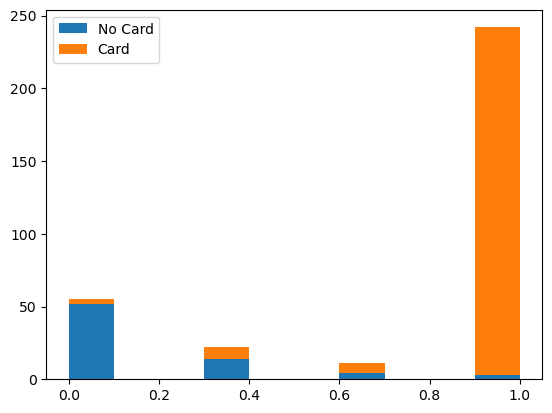

In [ ]:
plt.hist([test[test.card == 0].vote, test[test.card == 1].vote],
         stacked=True, label=["No Card", "Card"])
plt.legend()
plt.title("Ensemble Vote Mean Distribution")

In [72]:
test[np.logical_and(test.card==1, test.vote == 0)]

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active,k5cluster,k2cluster,svmclass,treepred,treeclass,fnnpred,fnnclass,vote
1270,1,0,29.08333,2.2,0.000545,0.0,0,0,0,9,1,0,4,0,0,0.028571,False,0.130750,False,0.0
1119,1,0,23.00000,2.9,0.000414,0.0,0,0,1,12,1,0,4,0,0,0.028571,False,0.389465,False,0.0
949,1,1,48.75000,2.7,0.000444,0.0,0,1,0,120,1,3,2,1,0,0.000000,False,0.130750,False,0.0
